In [ ]:
import requests
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import os
from urllib.parse import urlparse

class DynamicGroundingDINO:
    def __init__(self, model_id="IDEA-Research/grounding-dino-tiny", device="auto"):
        """
        Initialize the Grounding DINO model

        Args:
            model_id: Model identifier from HuggingFace
            device: Device to run on ("cuda", "cpu", or "auto")
        """
        if device == "auto":
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
        else:
            self.device = device

        print(f"Loading model on {self.device}...")
        self.processor = AutoProcessor.from_pretrained(model_id)
        self.model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(self.device)
        print("Model loaded successfully!")

    def load_image(self, image_source):
        """
        Load image from various sources

        Args:
            image_source: Can be URL, local file path, or PIL Image
        """
        if isinstance(image_source, str):
            if self._is_url(image_source):
                # Load from URL
                try:
                    response = requests.get(image_source, stream=True)
                    response.raise_for_status()
                    image = Image.open(response.raw)
                    print(f"Loaded image from URL: {image_source}")
                except Exception as e:
                    raise ValueError(f"Failed to load image from URL: {e}")
            else:
                # Load from local file
                if os.path.exists(image_source):
                    image = Image.open(image_source)
                    print(f"Loaded local image: {image_source}")
                else:
                    raise FileNotFoundError(f"Image file not found: {image_source}")
        elif isinstance(image_source, Image.Image):
            image = image_source
            print("Using provided PIL Image")
        else:
            raise ValueError("image_source must be URL, file path, or PIL Image")

        # Convert to RGB if needed
        if image.mode != 'RGB':
            image = image.convert('RGB')

        return image

    def _is_url(self, string):
        """Check if string is a valid URL"""
        try:
            result = urlparse(string)
            return all([result.scheme, result.netloc])
        except:
            return False

    def detect_objects(self, image_source, text_queries, box_threshold=0.4, text_threshold=0.3):
        """
        Detect objects in image based on text queries

        Args:
            image_source: Image source (URL, file path, or PIL Image)
            text_queries: List of text descriptions to search for
            box_threshold: Confidence threshold for bounding boxes
            text_threshold: Confidence threshold for text matching
        """
        # Load image
        image = self.load_image(image_source)

        # Prepare text queries
        if isinstance(text_queries, str):
            text_queries = [text_queries]
        text_labels = [text_queries]

        print(f"Searching for: {', '.join(text_queries)}")
        print(f"Thresholds - Box: {box_threshold}, Text: {text_threshold}")

        # Process inputs
        inputs = self.processor(images=image, text=text_labels, return_tensors="pt").to(self.device)

        # Run inference
        with torch.no_grad():
            outputs = self.model(**inputs)

        # Post-process results
        results = self.processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            box_threshold=box_threshold,
            text_threshold=text_threshold,
            target_sizes=[image.size[::-1]]
        )

        return image, results[0]

    def generate_colors(self, labels):
        """Generate distinct colors for different labels"""
        unique_labels = list(set(labels))
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
        color_map = {label: colors[i] for i, label in enumerate(unique_labels)}
        return color_map

    def visualize_results(self, image, results, save_path=None, figsize=(12, 8),
                         show_confidence=True, font_size=12):
        """
        Visualize detection results with bounding boxes

        Args:
            image: PIL Image
            results: Detection results from the model
            save_path: Optional path to save the visualization
            figsize: Figure size for matplotlib
            show_confidence: Whether to show confidence scores
            font_size: Font size for labels
        """
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        ax.imshow(image)

        boxes = results["boxes"]
        scores = results["scores"]
        labels = results["labels"]

        if len(boxes) == 0:
            print("No objects detected!")
            ax.set_title('No Objects Detected', fontsize=16, fontweight='bold')
            ax.axis('off')
            plt.tight_layout()
            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.show()
            return

        # Generate colors for labels
        color_map = self.generate_colors(labels)

        print(f"\nDetected {len(boxes)} objects:")

        # Draw bounding boxes
        for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
            box = box.tolist()
            x_min, y_min, x_max, y_max = box
            confidence = round(score.item(), 3)

            print(f"{i+1}. {label}: {confidence} at [{round(x_min)}, {round(y_min)}, {round(x_max)}, {round(y_max)}]")

            # Calculate dimensions
            width = x_max - x_min
            height = y_max - y_min

            # Get color
            color = color_map[label]

            # Create rectangle
            rect = patches.Rectangle(
                (x_min, y_min), width, height,
                linewidth=3, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)

            # Add label
            if show_confidence:
                text = f'{label}: {confidence}'
            else:
                text = label

            ax.text(
                x_min, y_min - 10,
                text,
                color='white',
                fontsize=font_size,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.8)
            )

        ax.set_xlim(0, image.size[0])
        ax.set_ylim(image.size[1], 0)
        ax.axis('off')
        ax.set_title(f'Detected Objects: {", ".join(set(labels))}',
                    fontsize=16, fontweight='bold')

        # Add legend
        legend_elements = [patches.Patch(color=color, label=label)
                          for label, color in color_map.items()]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Visualization saved to: {save_path}")

        plt.show()

    def run_detection(self, image_source, text_queries, box_threshold=0.4,
                     text_threshold=0.3, save_path=None, **viz_kwargs):
        """
        Complete detection pipeline

        Args:
            image_source: Image source (URL, file path, or PIL Image)
            text_queries: Text descriptions to search for
            box_threshold: Confidence threshold for bounding boxes
            text_threshold: Confidence threshold for text matching
            save_path: Optional path to save visualization
            **viz_kwargs: Additional arguments for visualization
        """
        try:
            # Run detection
            image, results = self.detect_objects(
                image_source, text_queries, box_threshold, text_threshold
            )

            # Visualize results
            self.visualize_results(image, results, save_path, **viz_kwargs)

            return image, results

        except Exception as e:
            print(f"Error during detection: {e}")
            return None, None

# Example usage and interactive functions
def quick_detect(image_source, queries, box_threshold=0.4, text_threshold=0.3):
    """Quick detection function"""
    detector = DynamicGroundingDINO()
    return detector.run_detection(image_source, queries, box_threshold, text_threshold)

def interactive_detection():
    """Interactive detection with user input"""
    detector = DynamicGroundingDINO()

    print("=== Dynamic Grounding DINO Object Detection ===")

    while True:
        print("\nOptions:")
        print("1. Detect objects in image")
        print("2. Quit")

        choice = input("\nEnter your choice (1-2): ").strip()

        if choice == "2":
            break
        elif choice == "1":
            # Get image source
            image_source = input("Enter image URL or file path: ").strip()

            # Get text queries
            queries_input = input("Enter objects to detect (comma-separated): ").strip()
            queries = [q.strip() for q in queries_input.split(",")]

            # Get thresholds
            try:
                box_thresh = float(input("Box threshold (0.4): ") or "0.4")
                text_thresh = float(input("Text threshold (0.3): ") or "0.3")
            except:
                box_thresh, text_thresh = 0.4, 0.3

            # Run detection
            detector.run_detection(image_source, queries, box_thresh, text_thresh)
        else:
            print("Invalid choice!")

Loading model on cuda...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Model loaded successfully!
Loaded image from URL: http://images.cocodataset.org/val2017/000000039769.jpg
Searching for: a cat, a remote control, a person
Thresholds - Box: 0.4, Text: 0.3


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:95: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)



Detected 3 objects:
1. a remote control: 0.526 at [38, 70, 177, 119]
2. a cat: 0.471 at [345, 24, 636, 375]
3. a cat: 0.477 at [12, 51, 317, 472]


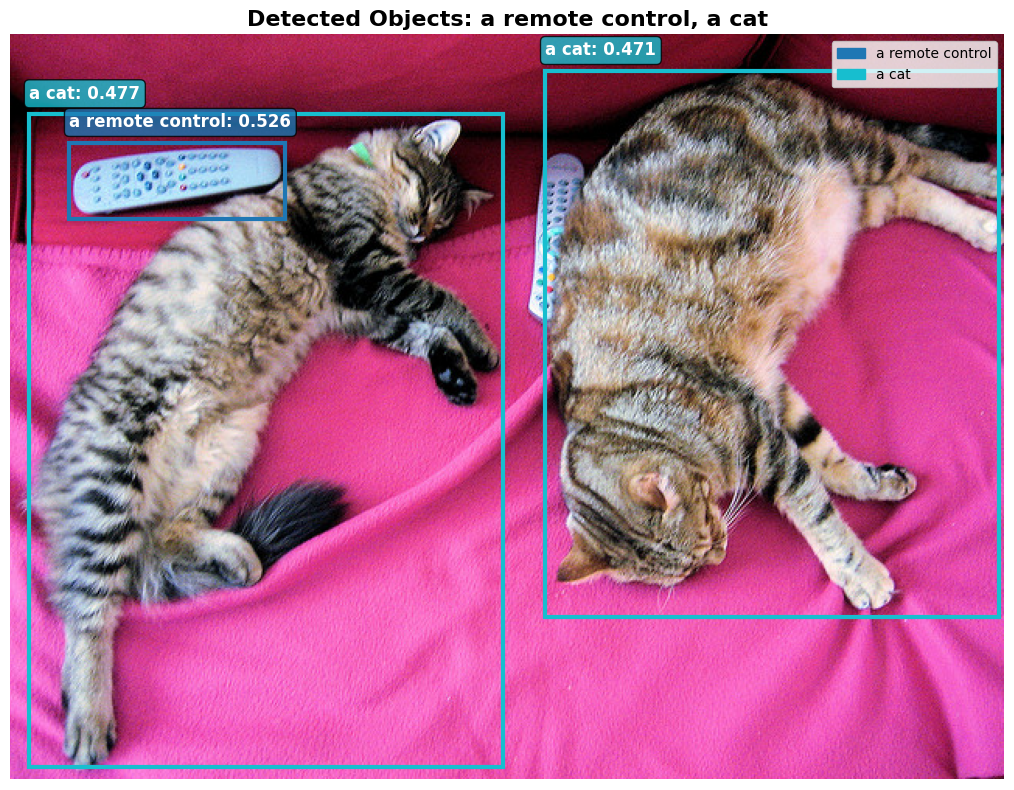

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480>,
 {'scores': tensor([0.5265, 0.4708, 0.4769], device='cuda:0'),
  'boxes': tensor([[ 38.2546,  69.9343, 176.8814, 118.5638],
          [344.7035,  23.6209, 636.3396, 374.7962],
          [ 12.4487,  51.4885, 317.2027, 471.5847]], device='cuda:0'),
  'text_labels': ['a remote control', 'a cat', 'a cat'],
  'labels': ['a remote control', 'a cat', 'a cat']})

In [ ]:
detector = DynamicGroundingDINO()

# Example 1: Basic detection
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
queries = ["a cat", "a remote control", "a person"]
detector.run_detection(image_url, queries)

# Example 2: Custom thresholds and save
# detector.run_detection(
#     image_url,
#     ["furniture", "electronics"],
#     box_threshold=0.3,
#     text_threshold=0.25,
#     save_path="detection_results.png"
# )

# Example 3: Interactive mode
# interactive_detection()

Loading model on cuda...
Model loaded successfully!
Loaded local image: /content/dog.jpg
Searching for: dog, ball, tree
Thresholds - Box: 0.4, Text: 0.3

Detected 16 objects:
1. dog: 0.629 at [3164, 1601, 3997, 2217]
2. dog: 0.562 at [2, 1456, 687, 2216]
3. dog: 0.605 at [668, 1470, 1228, 2101]
4. dog: 0.589 at [1025, 924, 1438, 1840]
5. dog: 0.526 at [1670, 1014, 2009, 1948]
6. dog: 0.514 at [349, 861, 764, 1735]
7. dog: 0.56 at [3059, 930, 3617, 2034]
8. dog: 0.508 at [2399, 1181, 2806, 1986]
9. dog: 0.554 at [1430, 1003, 1725, 1872]
10. dog: 0.436 at [2714, 1061, 3110, 2009]
11. dog: 0.633 at [1244, 1505, 1630, 2366]
12. tree: 0.445 at [3, 2, 3997, 886]
13. dog: 0.528 at [1945, 1360, 2300, 1985]
14. dog: 0.478 at [2261, 1429, 2464, 1944]
15. dog: 0.473 at [1984, 961, 2345, 1446]
16. dog: 0.502 at [2397, 902, 2765, 1636]


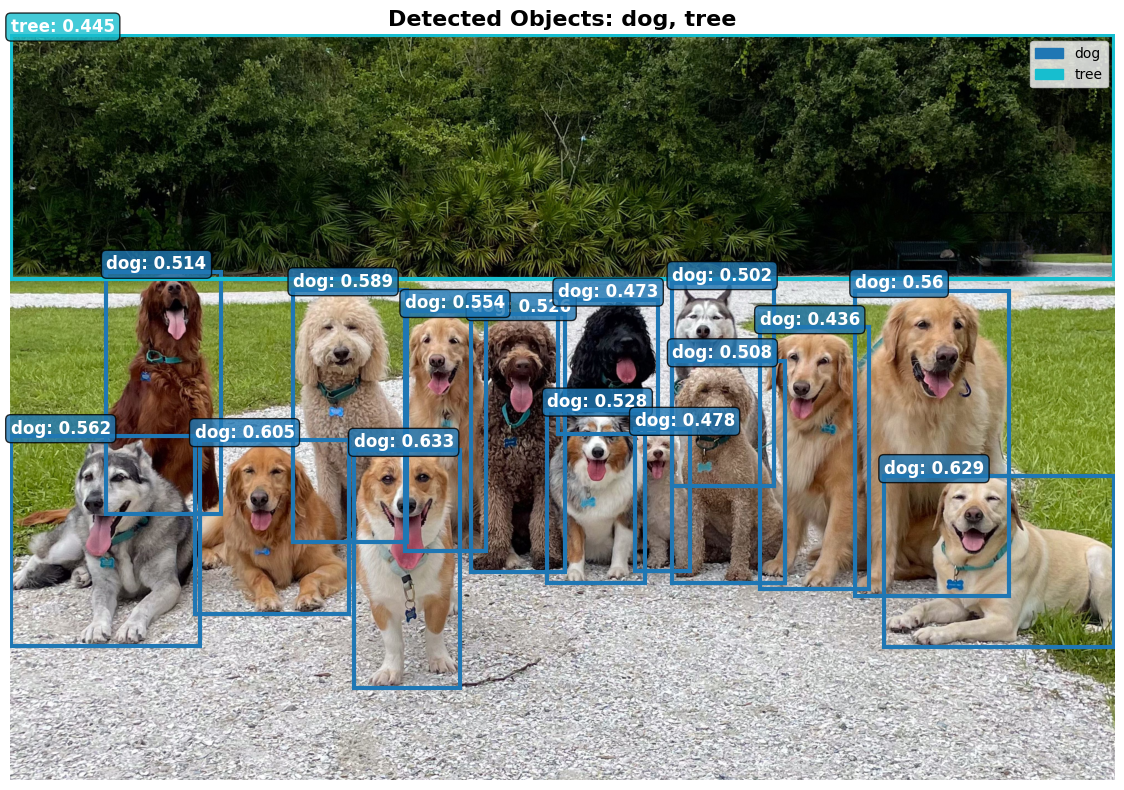

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=4000x2700>,
 {'scores': tensor([0.6291, 0.5619, 0.6053, 0.5886, 0.5255, 0.5136, 0.5597, 0.5082, 0.5540,
          0.4356, 0.6333, 0.4454, 0.5279, 0.4780, 0.4731, 0.5017],
         device='cuda:0'),
  'boxes': tensor([[3.1642e+03, 1.6007e+03, 3.9968e+03, 2.2169e+03],
          [2.4879e+00, 1.4560e+03, 6.8714e+02, 2.2164e+03],
          [6.6816e+02, 1.4703e+03, 1.2281e+03, 2.1006e+03],
          [1.0248e+03, 9.2394e+02, 1.4376e+03, 1.8399e+03],
          [1.6698e+03, 1.0139e+03, 2.0090e+03, 1.9484e+03],
          [3.4914e+02, 8.6066e+02, 7.6384e+02, 1.7355e+03],
          [3.0591e+03, 9.2993e+02, 3.6165e+03, 2.0341e+03],
          [2.3986e+03, 1.1812e+03, 2.8057e+03, 1.9859e+03],
          [1.4300e+03, 1.0026e+03, 1.7248e+03, 1.8718e+03],
          [2.7144e+03, 1.0613e+03, 3.1097e+03, 2.0087e+03],
          [1.2441e+03, 1.5055e+03, 1.6302e+03, 2.3658e+03],
          [3.0540e+00, 1.7020e+00, 3.9965e+03, 8.8601e+02],
          [1.9453

In [ ]:
# Example 4: Quick detection function
quick_detect("/content/dog.jpg", ["dog", "ball", "tree"])